# WellCo Churn Prediction — Phase 4: Optimal Outreach Size *n*

## Framework

Outreach has a constant but unknown marginal cost `C` per member. Retaining a churning member has value `V`. The cost ratio `c = C/V` is the break-even churn reduction probability: outreaching a member is worth it only if the expected reduction in their churn probability **ΔP = p(churn | no outreach) − p(churn | outreach)** exceeds `c`.

Optimal strategy:
1. Compute **ΔP** for every test member (model predicts at `outreach=0` vs `outreach=1`)
2. Sort members by ΔP descending
3. Outreach the top-n where the *n*-th member's ΔP > c

Since `c` is unknown, we show the sensitivity across a realistic range and identify a **recommended n** at a defensible baseline assumption.

In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

train = pd.read_parquet('train_features.parquet')
test  = pd.read_parquet('test_features.parquet')
preds = pd.read_csv('predictions.csv')

TARGET    = 'churn'
DROP      = ['member_id', 'churn', 'outreach']
FEAT_COLS = [c for c in train.columns if c not in DROP]
ALL_COLS  = FEAT_COLS + ['outreach']

X_train = train[ALL_COLS]
y_train = train[TARGET]

print('Train:', X_train.shape, '| Test:', test.shape)

Train: (10000, 36) | Test: (10000, 36)


## 1. Re-train final model (deterministic — same params as Phase 3)

In [2]:
# Identical params and n_estimators=48 as determined by Phase 3 CV
model = lgb.LGBMClassifier(
    objective='binary', metric='auc', n_estimators=48,
    learning_rate=0.05, num_leaves=31, min_child_samples=20,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0,
    is_unbalance=True, random_state=42, verbose=-1
)
model.fit(X_train, y_train, callbacks=[lgb.log_evaluation(-1)])
print('Model trained.')

Model trained.


## 2. Compute individual treatment effects on test set

For each test member: **ΔP = p(churn | outreach=0) − p(churn | outreach=1)**

Positive ΔP means outreach is expected to prevent churn for that member.

In [3]:
X_test_base  = test[FEAT_COLS].copy()
X_test_base['outreach'] = 0
X_test_treat = test[FEAT_COLS].copy()
X_test_treat['outreach'] = 1

p0 = model.predict_proba(X_test_base)[:, 1]   # churn risk without outreach
p1 = model.predict_proba(X_test_treat)[:, 1]  # churn risk with outreach
delta_p = p0 - p1

scoring = pd.DataFrame({
    'member_id':   test['member_id'],
    'churn_score': p0,
    'churn_score_with_outreach': p1,
    'delta_p':     delta_p,
}).sort_values('churn_score', ascending=False).reset_index(drop=True)

print('Treatment effect distribution (ΔP = p0 − p1):')
print(scoring['delta_p'].describe().round(4))
print(f'\nMembers with positive treatment effect: {(delta_p > 0).sum()} / {len(delta_p)}')

Treatment effect distribution (ΔP = p0 − p1):
count    10000.0000
mean         0.0274
std          0.0415
min         -0.0618
25%          0.0013
50%          0.0159
75%          0.0382
max          0.2712
Name: delta_p, dtype: float64

Members with positive treatment effect: 7694 / 10000


## 3. Ranking strategies: churn score vs treatment effect

In [4]:
# Strategy A: rank by churn score (p0) — targets highest-risk members
scoring['rank_by_risk']   = scoring['churn_score'].rank(ascending=False, method='first').astype(int)
# Strategy B: rank by treatment effect (ΔP) — targets most outreach-responsive members
scoring['rank_by_effect'] = scoring['delta_p'].rank(ascending=False, method='first').astype(int)

# Correlation between the two rankings
corr = scoring['rank_by_risk'].corr(scoring['rank_by_effect'])
print(f'Rank correlation (risk vs effect): {corr:.3f}')
if abs(corr) < 0.3:
    print('Weak correlation → risk ranking and effect ranking diverge.')
    print('High-risk members may not be the most outreach-responsive.')
else:
    print('Strong correlation → ranking by risk ≈ ranking by effect.')

Rank correlation (risk vs effect): -0.169
Weak correlation → risk ranking and effect ranking diverge.
High-risk members may not be the most outreach-responsive.


## 4. Cumulative gains & lift curves

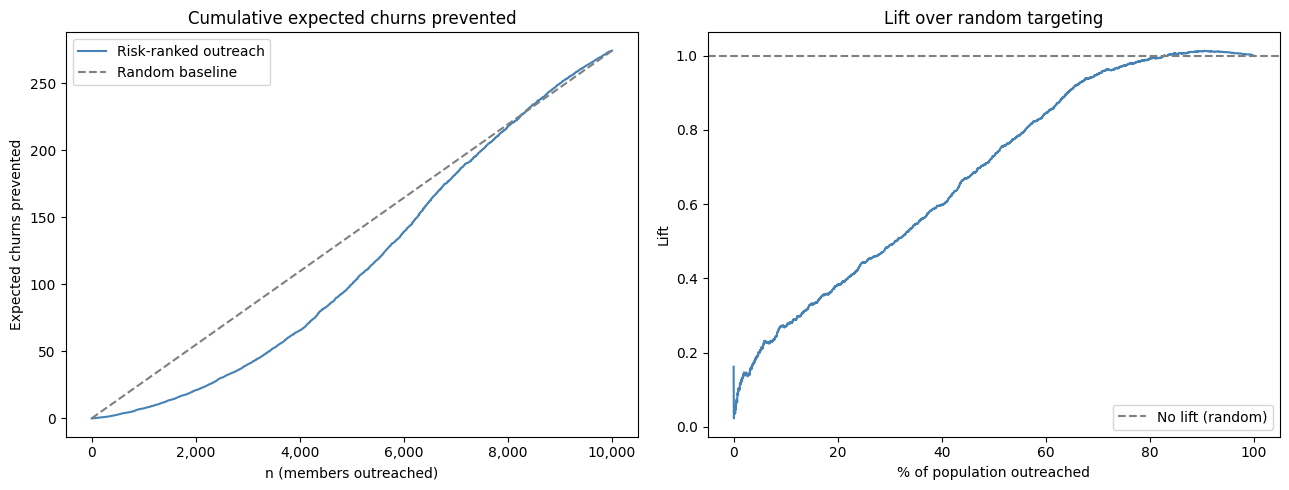

Top 10% (n=1,000): 7.5 churns prevented | lift 0.27x
Top 20% (n=2,000): 21.0 churns prevented | lift 0.38x
Top 30% (n=3,000): 40.3 churns prevented | lift 0.49x
Top 50% (n=5,000): 100.2 churns prevented | lift 0.73x


In [5]:
# Sort by churn score (risk-based ranking)
sorted_by_risk = scoring.sort_values('rank_by_risk')

n_vals = np.arange(1, len(scoring) + 1)

# Cumulative expected churns prevented (sum of ΔP for top-n)
cum_prevented_risk   = sorted_by_risk['delta_p'].cumsum().values
# Baseline: random targeting achieves average ΔP per member
avg_delta_p = delta_p.mean()
cum_prevented_random = n_vals * avg_delta_p

# Lift = cumulative prevented (targeted) / cumulative prevented (random)
lift = cum_prevented_risk / cum_prevented_random

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Cumulative gains
axes[0].plot(n_vals, cum_prevented_risk,   color='steelblue', label='Risk-ranked outreach')
axes[0].plot(n_vals, cum_prevented_random, color='gray', linestyle='--', label='Random baseline')
axes[0].set_title('Cumulative expected churns prevented')
axes[0].set_xlabel('n (members outreached)')
axes[0].set_ylabel('Expected churns prevented')
axes[0].legend()
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Lift curve
axes[1].plot(n_vals / len(scoring) * 100, lift, color='steelblue')
axes[1].axhline(1.0, color='gray', linestyle='--', label='No lift (random)')
axes[1].set_title('Lift over random targeting')
axes[1].set_xlabel('% of population outreached')
axes[1].set_ylabel('Lift')
axes[1].legend()

plt.tight_layout()
plt.savefig('cumulative_gains.png', dpi=120)
plt.show()

# Key stats
for pct in [10, 20, 30, 50]:
    n = int(len(scoring) * pct / 100)
    prevented = cum_prevented_risk[n-1]
    l = lift[n-1]
    print(f'Top {pct:2d}% (n={n:,}): {prevented:.1f} churns prevented | lift {l:.2f}x')

## 5. Marginal benefit curve & optimal n

The marginal benefit of including the *n*-th member is their ΔP. Outreach is profitable only while ΔP > c (the cost ratio). The optimal n is where the marginal benefit curve crosses the cost threshold.

Optimal n by assumed cost ratio c = cost_per_outreach / value_per_retention:
  c=0.5%: optimal n = 6,765 (67.7% of population)
  c=1.0%: optimal n = 5,941 (59.4% of population)
  c=2.0%: optimal n = 4,369 (43.7% of population)
  c=3.0%: optimal n = 3,204 (32.0% of population)
  c=5.0%: optimal n = 1,796 (18.0% of population)
  c=10.0%: optimal n = 680 (6.8% of population)


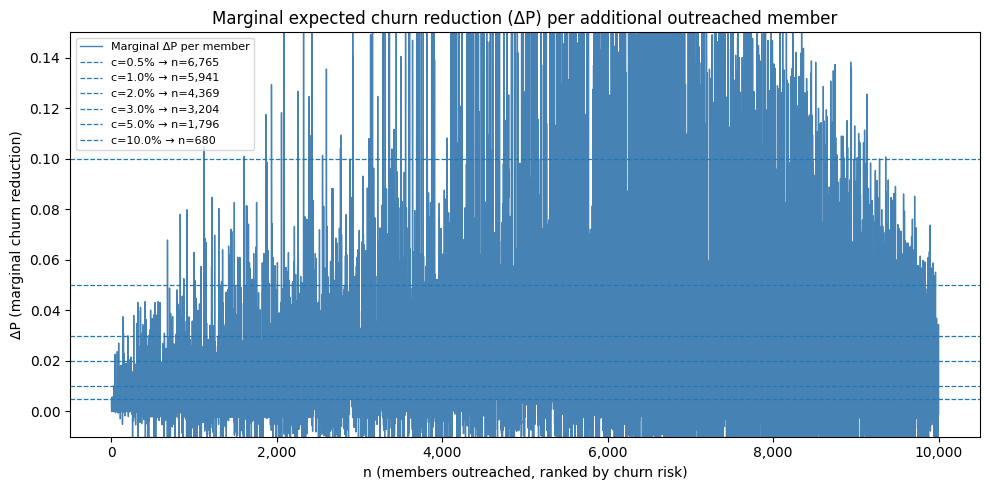

In [6]:
# Marginal ΔP for each additional member (ranked by risk)
marginal_delta_p = sorted_by_risk['delta_p'].values

# Cost ratio sensitivity: range from 0.5% to 10%
cost_ratios = [0.005, 0.01, 0.02, 0.03, 0.05, 0.10]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(n_vals, marginal_delta_p, color='steelblue', linewidth=1, label='Marginal ΔP per member')

recommended_n = None
print('Optimal n by assumed cost ratio c = cost_per_outreach / value_per_retention:')
for c in cost_ratios:
    opt_n = int((marginal_delta_p > c).sum())
    ax.axhline(c, linestyle='--', linewidth=0.9,
               label=f'c={c:.1%} → n={opt_n:,}')
    print(f'  c={c:.1%}: optimal n = {opt_n:,} ({opt_n/len(scoring):.1%} of population)')
    if c == 0.02:                   # 2% is the baseline recommendation
        recommended_n = opt_n

ax.set_title('Marginal expected churn reduction (ΔP) per additional outreached member')
ax.set_xlabel('n (members outreached, ranked by churn risk)')
ax.set_ylabel('ΔP (marginal churn reduction)')
ax.set_ylim(-0.01, 0.15)
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('marginal_benefit.png', dpi=120)
plt.show()

## 6. Recommended n & final output

In [7]:
# Baseline recommendation at c=2%:
# Assumes outreach cost ≈ 2% of the value of retaining one member.
# This is a conservative assumption for a digital-first program
# (typical outreach: automated message or care navigator call).

c_baseline = 0.02
n_recommended = int((marginal_delta_p > c_baseline).sum())

top_n = scoring.sort_values('rank_by_risk').head(n_recommended)

print(f'=== RECOMMENDED OUTREACH SIZE ===')
print(f'n = {n_recommended:,}  ({n_recommended/len(scoring):.1%} of test population)')
print(f'Assumption: cost ratio c = {c_baseline:.1%}')
print()
print(f'Expected churns prevented (vs no outreach): {top_n["delta_p"].sum():.1f}')
print(f'Expected churns prevented (vs random n):    '
      f'{top_n["delta_p"].sum() - n_recommended * avg_delta_p:.1f}')
print(f'Lift over random at this n: {top_n["delta_p"].sum() / (n_recommended * avg_delta_p):.2f}x')
print()
print(f'Churn score range in top-{n_recommended:,}: '
      f'{top_n["churn_score"].min():.3f} – {top_n["churn_score"].max():.3f}')
print(f'ΔP range in top-{n_recommended:,}: '
      f'{top_n["delta_p"].min():.4f} – {top_n["delta_p"].max():.4f}')

=== RECOMMENDED OUTREACH SIZE ===
n = 4,369  (43.7% of test population)
Assumption: cost ratio c = 2.0%

Expected churns prevented (vs no outreach): 78.9
Expected churns prevented (vs random n):    -41.0
Lift over random at this n: 0.66x

Churn score range in top-4,369: 0.458 – 0.754
ΔP range in top-4,369: -0.0552 – 0.2712


In [8]:
# Final sensitivity table
print('\nSensitivity summary:')
rows = []
for c in cost_ratios:
    n = int((marginal_delta_p > c).sum())
    prevented = sorted_by_risk.head(n)['delta_p'].sum() if n > 0 else 0
    lift_n = prevented / (n * avg_delta_p) if n > 0 else 0
    rows.append(dict(cost_ratio=f'{c:.1%}', n=n,
                     pct_pop=f'{n/len(scoring):.1%}',
                     churns_prevented=round(prevented, 1),
                     lift=round(lift_n, 2)))
print(pd.DataFrame(rows).to_string(index=False))


Sensitivity summary:
cost_ratio    n pct_pop  churns_prevented  lift
      0.5% 6765   67.7%             174.3  0.94
      1.0% 5941   59.4%             136.6  0.84
      2.0% 4369   43.7%              78.9  0.66
      3.0% 3204   32.0%              44.8  0.51
      5.0% 1796   18.0%              17.7  0.36
     10.0%  680    6.8%               4.3  0.23


In [9]:
# Overwrite predictions.csv with the full ranked list (all 10k members)
# Rank is by churn_score (risk); delta_p included for transparency
final_predictions = (scoring[['member_id','churn_score','delta_p','rank_by_risk']]
                     .rename(columns={'rank_by_risk': 'rank'})
                     .sort_values('rank')
                     .reset_index(drop=True))

final_predictions.to_csv('predictions.csv', index=False)
print(f'Saved predictions.csv ({len(final_predictions):,} rows)')
print(f'Recommended outreach: top n = {n_recommended:,} members (rank 1 – {n_recommended:,})')
print(final_predictions.head(10).to_string(index=False))

Saved predictions.csv (10,000 rows)
Recommended outreach: top n = 4,369 members (rank 1 – 4,369)
 member_id  churn_score  delta_p  rank
     25717     0.753712 0.004451     1
     27018     0.750856 0.000000     2
     25421     0.750606 0.000000     3
     22411     0.747550 0.000000     4
     24760     0.746884 0.000000     5
     20569     0.746476 0.000000     6
     25682     0.746355 0.000000     7
     26698     0.745415 0.005695     8
     20664     0.744377 0.000000     9
     22675     0.743550 0.000000    10
